In [1]:
# created by Yann Buchholzer and Julius ...
import numpy as np
import matplotlib.pyplot as plt

In [52]:

# Create datasample, calculate pi and radius

def pi_x(experiments, pairs, dimension):
    
    points = np.random.uniform(low = -1.0, high = 1.0, size = (dimension, pairs, experiments)) # generating the points
    radius_squared = (points**2).sum(axis=0) 
    inside_the_circle = (radius_squared <= 1)
    inside_the_square = ((-1.0 <= points[0]) & (points[0] <= 1.0) & 
                         (-1.0 <= points[1]) & (points[1] <= 1.0))
    pi_by_4 = inside_the_circle.sum(axis=0) / inside_the_square.sum(axis=0)
    pi = 4 * pi_by_4
    sigma = np.sqrt(4*inside_the_circle.sum()/(pairs-1))
    
    return radius_squared, pi,sigma, inside_the_circle

## 1.1 Just do one big experiment

In [53]:
# Experimental setup

experiments = 1
dimension = 2
pairs = 10000

# Calculated pi and radius

radius, pi_1,sigma, inside_the_circle = pi_x(experiments,pairs,dimension)

print("The mean of this experiment is",pi_1.mean(), "while the standard derivation is",
sigma) # From sheet should be 1.6, but we have only one experiment, so pi_x = final answer => uncertainty =0?



The mean of this experiment is 3.146 while the standard derivation is 1.7737853961128291


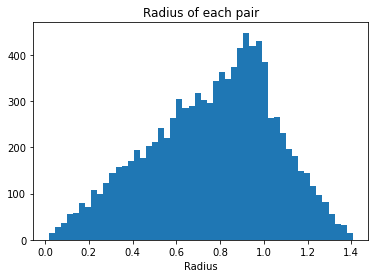

In [9]:
plt.hist(np.sqrt(radius), bins = 50)
plt.title("Radius of each pair")
plt.xlabel("Radius")
plt.show()


Explanation: We are looking at the radius $r= \sqrt{x^2+y^2}$ with $x,y \in [0,1]$ randomly distributed. 

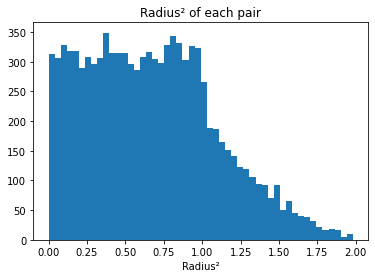

In [16]:
plt.hist(radius, bins = 50)
plt.title("Radius² of each pair")
plt.xlabel("Radius²")
plt.show()

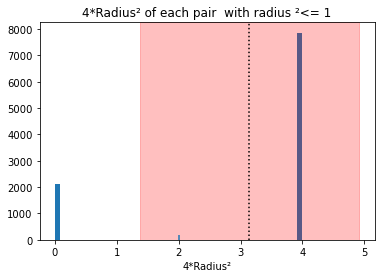

In [55]:

plt.hist(4*inside_the_circle , bins =50)
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_1.mean() - sigma, pi_1.mean() + sigma, alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
plt.vlines(4*radius[radius <= 1].mean(),0,175)
plt.title("4*Radius² of each pair  with radius ²<= 1")
plt.xlabel("4*Radius²")
plt.show()

## 1.2 Split into 100 experiments

In [56]:
# New experimental setup

experiments = 100
dimension = 2
pairs = 100

# Calculated pi and radius

pi_2 = pi_x(experiments,pairs,dimension)[1]

print("Estimate π_x for each experiment:\n", pi_2)
print("The mean of this experiment is", pi_2.mean(), "while the standard derivation is",
pi_2.std())


Estimate π_x for each experiment:
 [3.   3.04 3.12 3.16 3.2  3.   2.96 3.24 2.96 3.08 3.16 3.08 3.16 3.16
 3.28 3.16 3.24 3.32 3.24 3.12 3.4  3.08 3.   2.88 3.28 3.08 3.16 3.12
 3.24 3.12 2.84 3.12 3.   3.24 3.08 3.16 3.   3.04 2.92 3.08 3.12 2.92
 3.4  3.2  3.04 3.2  3.2  3.04 3.36 3.28 2.92 3.16 2.96 3.24 3.2  3.
 3.   3.28 3.16 2.88 3.16 2.84 3.48 2.88 3.24 3.28 3.04 3.12 2.92 3.16
 2.96 3.04 3.4  2.96 3.36 3.12 3.24 3.24 3.2  3.28 3.04 3.32 3.2  3.36
 3.08 3.28 2.88 3.48 3.4  3.24 3.24 3.32 3.4  3.36 2.88 3.16 3.12 3.04
 3.28 3.32]
The mean of this experiment is 3.1439999999999997 while the standard derivation is 0.1518947003683802


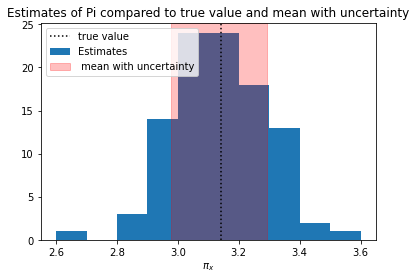

In [33]:

plt.hist(pi_2, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_2.mean() - pi_2.std(), pi_2.mean() + pi_2.std(), alpha=0.25, color = "red", 
            label = " mean with uncertainty"  )
plt.title("Estimates of Pi compared to true value and mean with uncertainty")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

## 1.3 A Zillion Little Experiments

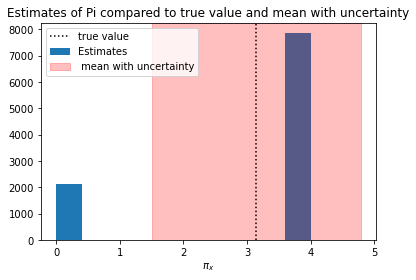

In [13]:
# New experimental setup

experiments = 10000
dimension = 2
pairs = 1

# Calculated pi and radius

pi_3 = pi_x(experiments,pairs,dimension)[1]


plt.hist(pi_3, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_3.mean() - pi_3.std(), pi_3.mean() + pi_3.std(), alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
plt.title("Estimates of Pi compared to true value and mean with uncertainty")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

### Explanation:

We have 2 different cases: Either the pair is inside the circle or it is not inside the circle. If it is inside the circle we get $4\cdot1$ as result. If it is not we get 0, since we look for inside_the_circle.sum(axis=0) / inside_the_square.sum(axis=0) = inside_the_circle/ inside_the_square.

## 1.4 Stop and think

In [17]:
print(pi_1.mean(),pi_1.std())
print(pi_2.mean(),pi_2.std())
print(pi_3.mean(),pi_3.std())
print(np.pi)

3.1612 0.0
3.1224000000000003 0.1629547176365263
3.1448 1.6399490723799932
3.141592653589793


All computational results are close to the true result of pi. The difference between these methods lies in different uncertainties. 

The standard deviation of a single experiment doesn't make much sense, since the final answer and $\pi_x$ are everytime exactly the same, therefore you would get always an uncertainty of 0, which is not the case.



## 1.5 More Experiments vs. Longer Experiments

In [44]:
pairs = np.array([10,100,1000,10000])
experiments = np.array([10,100,1000,10000])
X_P = []

pi_mean = np.zeros(16) #result of (X,P) experiment  
pi_all = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
pi_std = np.zeros(16)

for a in range(len(pairs)):
    for c in range(len(experiments)):
        pi_mean[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].mean()    # Final result of experiment (X,P)
        pi_std[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].std()      # Uncertainty of experiment (X,P)
        pi_all[c*4+a] = pi_x(experiments[c],pairs[a],2)[1] # all calculated pi_x
        X_P = np.append(X_P,(experiments[c],pairs[a]))                # List of used combination
        
pi_tot_std = np.sqrt(1/15*np.sum((pi_mean-pi_mean.mean())**2)) 
        
print("The final estimate of pi is",pi_mean.mean(),"+-",pi_tot_std)
#print(pi_all)
print(X_P)

The final estimate of pi is 3.14378108 +- 0.01585535732057788
[   10.    10.   100.    10.  1000.    10. 10000.    10.    10.   100.
   100.   100.  1000.   100. 10000.   100.    10.  1000.   100.  1000.
  1000.  1000. 10000.  1000.    10. 10000.   100. 10000.  1000. 10000.
 10000. 10000.]


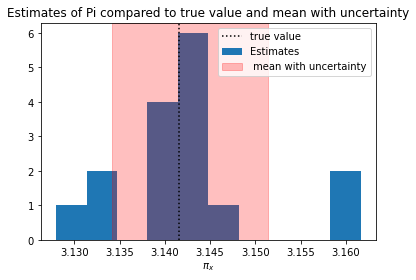

In [26]:
# 1.5 zweiter Punkt. Ist pi_x von allen Experimenten oder das finale pi_x gemeint? Erster plot schaut nur finales pi_x

plt.hist(pi_mean, label = "Estimates")
plt.axvline(np.pi, color='black', zorder=1, linestyle=':', label = "true value")
plt.axvspan(pi_mean.mean() - pi_tot_std, pi_mean.mean()+ pi_tot_std, alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
plt.title("Estimates of final Pi from all experiments compared to true value and mean with uncertainty of all experiments")
plt.xlabel("$π_x$")
plt.legend()
plt.show()

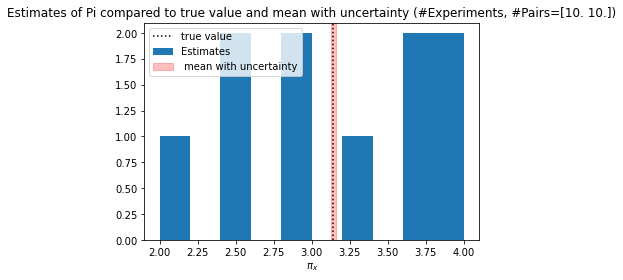

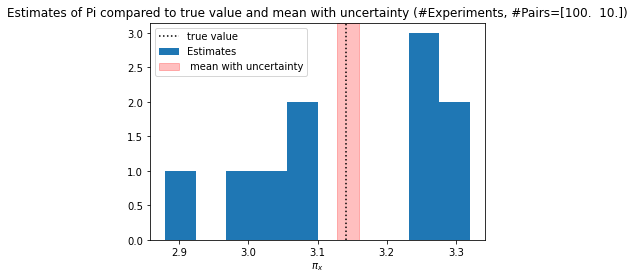

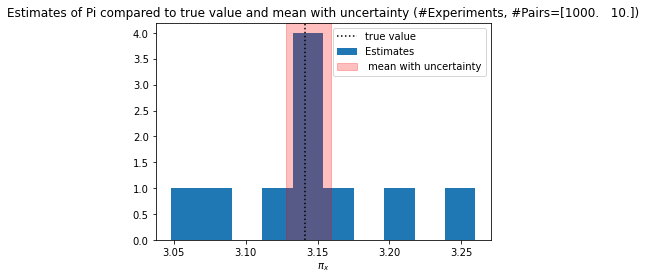

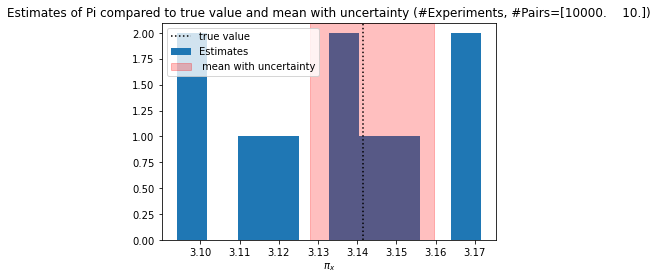

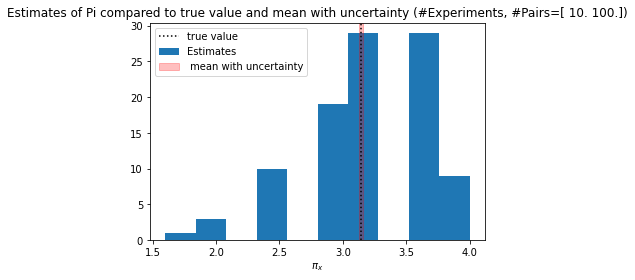

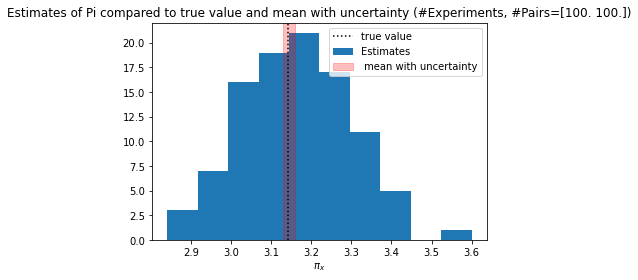

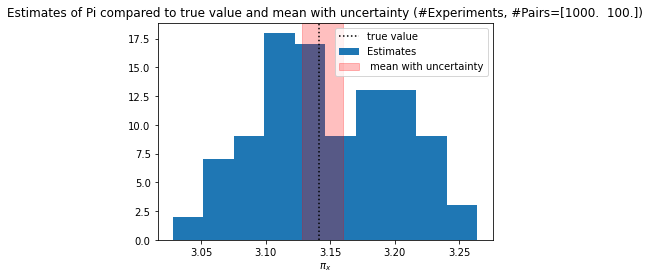

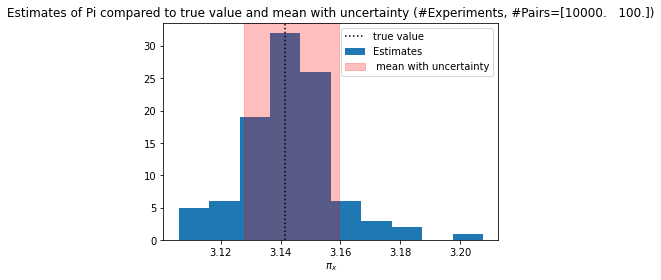

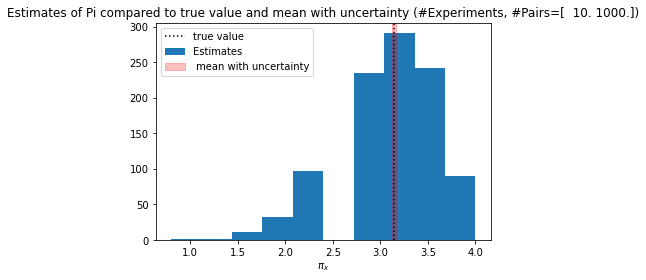

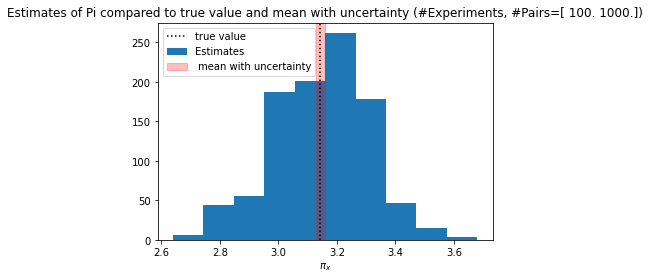

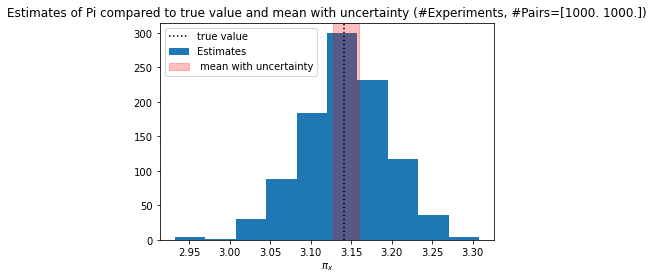

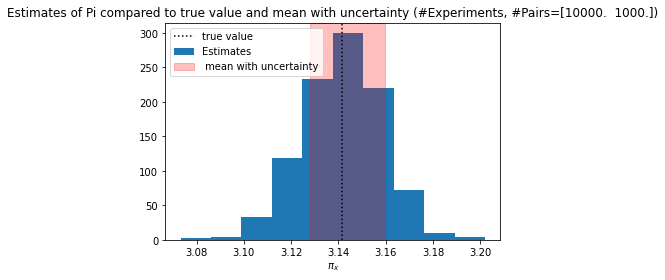

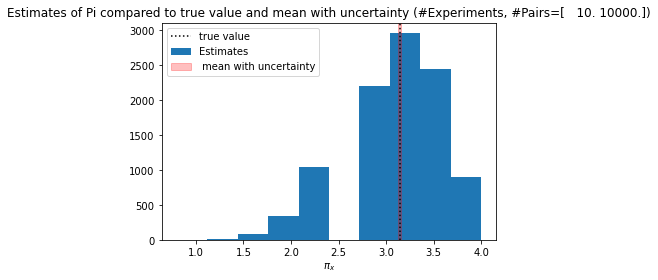

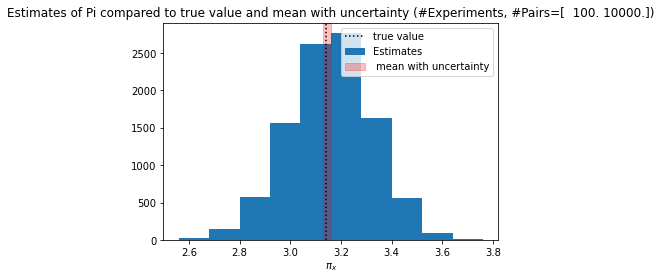

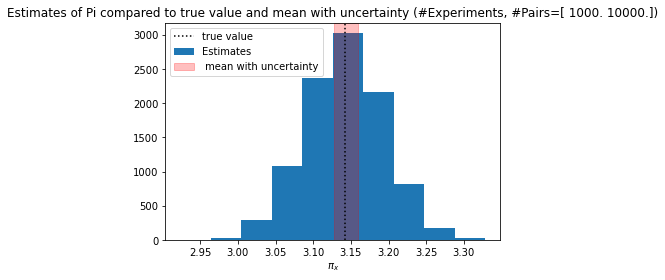

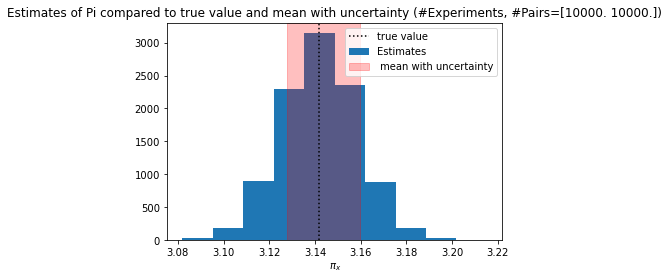

In [57]:
# 1.5 zweiter Punkt.Dieser plot schaut alle pi_x
X_P = X_P.reshape(16,2)
for x in range(0,16):
    plt.hist(pi_all[x], label = "Estimates", bins = 10)
    plt.axvline(np.pi, color='black', zorder = 1, linestyle = ':', label = "true value")
    plt.axvspan(pi_mean.mean() - pi_tot_std, pi_mean.mean()+ pi_tot_std, alpha=0.25, color = "red" ,label= " mean with uncertainty"  )
    plt.title(f"Estimates of Pi compared to true value and mean with uncertainty (#Experiments, #Pairs={X_P[x]})")
    plt.xlabel("$π_x$")
    plt.legend()
    plt.show()

In [58]:
X_P = X_P.reshape(16,2)
print(X_P) # used experiment, pair combination 

# seperate the 16 results by fixed pairs
pi_std_fixed_pairs = pi_std.reshape(4,4)
pi_mean_fixed_pairs = pi_mean.reshape(4,4)

print(pi_std_fixed_pairs)
print(pi_mean_fixed_pairs.mean(axis=1),pi_std_fixed_pairs.mean(axis=1))


[[   10.    10.]
 [  100.    10.]
 [ 1000.    10.]
 [10000.    10.]
 [   10.   100.]
 [  100.   100.]
 [ 1000.   100.]
 [10000.   100.]
 [   10.  1000.]
 [  100.  1000.]
 [ 1000.  1000.]
 [10000.  1000.]
 [   10. 10000.]
 [  100. 10000.]
 [ 1000. 10000.]
 [10000. 10000.]]
[[0.59464275 0.16124515 0.03877319 0.01580602]
 [0.50317393 0.15367498 0.04849518 0.01582125]
 [0.51711183 0.16367013 0.0505092  0.01640663]
 [0.51662186 0.16297906 0.05184114 0.01647559]]
[3.13437    3.126647   3.1401051  3.14106787] [0.20261678 0.18029133 0.18692444 0.18697942]


You should have the same number of pairs and experiment to minimize the uncertainty, if you have a fix X*P

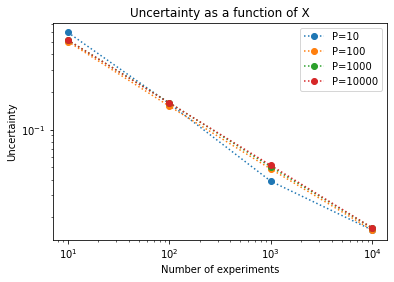

In [70]:
plt.plot(experiments, pi_std_fixed_pairs[0], linestyle = ':', marker = 'o', label = 'P=10')
plt.plot(experiments, pi_std_fixed_pairs[1], linestyle = ':', marker = 'o', label = 'P=100')
plt.plot(experiments, pi_std_fixed_pairs[2], linestyle = ':', marker = 'o', label = 'P=1000')
plt.plot(experiments, pi_std_fixed_pairs[3], linestyle = ':', marker = 'o', label = 'P=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of experiments')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('Uncertainty as a function of X')
plt.show()

In [72]:
pi_std_fixed_experiments = pi_std_fixed_pairs.T


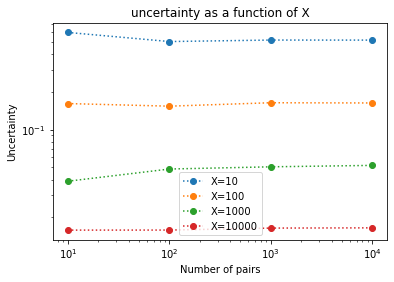

In [71]:
plt.plot(pairs, pi_std_fixed_experiments[0], linestyle = ':', marker = 'o', label = 'X=10')
plt.plot(pairs, pi_std_fixed_experiments[1], linestyle = ':', marker = 'o', label = 'X=100')
plt.plot(pairs, pi_std_fixed_experiments[2], linestyle = ':', marker = 'o', label = 'X=1000')
plt.plot(pairs, pi_std_fixed_experiments[3], linestyle = ':', marker = 'o', label = 'X=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of pairs')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('uncertainty as a function of X')
plt.show()

With increasing number of pairs and fixed experiments the logharithm of the uncertainties is roughly constant, while it goes linearly down with fixed number of pairs and increasing experiments.